In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
dat = gpd.read_file('neigh_reviews_subset.gpkg')

In [3]:
dat['text'] = dat.text.str.lower()
dat = dat.dropna(subset=['text', 'gentrified']).reset_index(drop=True)

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import re

# 1. Setup (assuming 'undf' is a DataFrame)
# corpus_undf <- corpus(undf, text_field = "text")
texts = dat['text']

# 2. Preprocessing Function (tokens, remove_punct, remove_numbers, wordstem)
stemmer = SnowballStemmer("english")
stop_words = set(stopwords.words('english'))

def preprocess(text):
    # remove_punct and remove_numbers using regex
    #text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # tokens_wordstem and stopwords remove
    tokens = [stemmer.stem(word) for word in text.split() if word not in stop_words]
    return " ".join(tokens)

# Apply preprocessing
processed_texts = texts.apply(preprocess)

# 3. Create DFM (Document-Feature Matrix)
# dfm <- dfm(toks)
vectorizer = CountVectorizer()
dfm = vectorizer.fit_transform(processed_texts)

# 4. Trim DFM (min_docfreq = 0.05)
# dfm_trim(dfm, min_docfreq = 0.05, docfreq_type = "prop")
trimmed_vectorizer = CountVectorizer(min_df=0.05)
dfm_trimmed = trimmed_vectorizer.fit_transform(processed_texts)

# Convert to DataFrame for viewing (optional)
dfm_trimmed_df = pd.DataFrame(
    dfm_trimmed.toarray(), 
    columns=trimmed_vectorizer.get_feature_names_out()
)

print(dfm_trimmed_df)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ellabartt/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


        actual  also  alway  amaz  anoth  appet  area  around  ask  atmospher  \
0            0     0      0     0      0      0     1       0    0          0   
1            0     0      1     0      0      0     0       0    0          0   
2            0     1      1     0      0      0     0       0    0          0   
3            0     1      0     0      0      0     0       0    0          0   
4            0     0      0     0      0      0     0       0    0          0   
...        ...   ...    ...   ...    ...    ...   ...     ...  ...        ...   
681784       0     1      0     0      0      0     0       0    0          0   
681785       0     1      0     2      0      0     0       0    0          0   
681786       0     1      0     1      0      0     0       0    0          0   
681787       0     1      0     0      0      0     0       0    0          0   
681788       0     1      0     0      2      0     0       0    0          0   

        ...  wasnt  way  we

In [4]:
dat['id'] = dat.index

In [7]:
from sklearn.model_selection import train_test_split
training, validation = train_test_split(
    dat, 
    train_size=0.75, 
    random_state=32123
)


In [8]:
#Create separate subsets for DFM
dfmat_train = dfm_trimmed_df.loc[training.index]
dfmat_val = dfm_trimmed_df.loc[validation.index]
X_train = dfmat_train
X_test = dfmat_val
y_train = dat.loc[training.index].gentrified
y_test = dat.loc[validation.index].gentrified

In [9]:
dfmat_train

,actual,also,alway,amaz,anoth,appet,area,around,ask,atmospher,...,wasnt,way,week,well,went,work,worth,would,year,your
103804,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
125950,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
416681,0,1,0,0,1,0,0,0,3,0,...,2,0,1,0,1,0,0,0,0,0
348278,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
469040,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
529997,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
262968,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
241115,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,1,0,0,0
218058,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import confusion_matrix, classification_report

lasso_model = LogisticRegression(penalty='l1', solver = 'saga', random_state=4323, )
lasso_model.fit(X_train, y_train)

testing = []
for i, j in enumerate(X_train.columns):
    testing.append({
        'word': j,
        'rank': lasso_model.coef_[0][i],
        'rank_abs': np.abs(lasso_model.coef_[0][i])
    })
importance = pd.DataFrame(testing)
importance = importance.sort_values(by = 'rank', ascending = False)

# --- 4. Out of Sample Predictions ---
# Probability predictions (type="response")
pred_probs = lasso_model.predict_proba(X_test)[:, 1]

# Confusion Matrix (Table)
# Since R's index 40 or 1 refers to specific lambdas, in Python you'd just 
# predict using the fitted model or specific thresholds.
print(confusion_matrix(y_test, lasso_model.predict(X_test)))

confusion_matrix(y_test, lasso_model.predict(X_test))

[[154493     51]
 [ 15889     15]]


array([[154493,     51],
       [ 15889,     15]])

In [11]:
print(classification_report(y_test, lasso_model.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95    154544
         1.0       0.23      0.00      0.00     15904

    accuracy                           0.91    170448
   macro avg       0.57      0.50      0.48    170448
weighted avg       0.84      0.91      0.86    170448



In [12]:
# --- 5. Cross-Validation (cv.glmnet) ---
# Cs is the number of inverse-lambdas to try
cv_model = LogisticRegressionCV(
    penalty='l1', 
    solver='saga', 
    cv=5, 
    scoring='accuracy', 
    class_weight='balanced' # Replaces manual weights
)
cv_model.fit(X_train, y_train)

testing2 = []
for i, j in enumerate(X_train.columns):
    testing2.append({
        'word': j,
        'rank': cv_model.coef_[0][i],
        'rank_abs': np.abs(cv_model.coef_[0][i])
    })
importance2 = pd.DataFrame(testing2)
importance2 = importance2.sort_values(by = 'rank', ascending = False)

pred_val = cv_model.predict(X_test)
tab_val = confusion_matrix(y_test, pred_val)
print("Final Validation Table:\n", tab_val)
importance2.head()

Final Validation Table:
 [[133874  20670]
 [ 12229   3675]]


,word,rank,rank_abs
16,beer,0.065896,0.065896
120,pizza,0.065700,0.065700
0,actual,0.000000,0.000000
124,portion,0.000000,0.000000
126,price,0.000000,0.000000


In [13]:
print(classification_report(y_test, cv_model.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.92      0.87      0.89    154544
         1.0       0.15      0.23      0.18     15904

    accuracy                           0.81    170448
   macro avg       0.53      0.55      0.54    170448
weighted avg       0.84      0.81      0.82    170448



In [14]:
importance2.tail()

,word,rank,rank_abs
68,get,0.0,0.0
69,give,0.0,0.0
70,go,0.0,0.0
71,good,0.0,0.0
196,your,0.0,0.0


In [5]:
import statsmodels.formula.api as smf

dat['authenticity'] = np.where(dat['text'].str.contains('authent'), 1, 0)
dat['beer'] = np.where(dat['text'].str.contains('beer'), 1, 0)
dat['simple'] = np.where(dat['text'].str.contains('simpl'), 1, 0)
dat['gentrified'] = dat['gentrified'].astype(int)
dat.columns


Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code_x',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'index_right', 'LISTNAME',
       'gentrified', 'review_id', 'user_id', 'useful', 'funny', 'cool', 'text',
       'date', 'geometry', 'id', 'authenticity', 'beer', 'simple'],
      dtype='object')

In [6]:
authenticity_model = smf.logit('gentrified ~ authenticity', data=dat).fit()
print(authenticity_model.summary())

Optimization terminated successfully.
         Current function value: 0.311943
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             gentrified   No. Observations:               681789
Model:                          Logit   Df Residuals:                   681787
Method:                           MLE   Df Model:                            1
Date:                Thu, 07 May 2026   Pseudo R-squ.:               0.0001632
Time:                        13:38:09   Log-Likelihood:            -2.1268e+05
converged:                       True   LL-Null:                   -2.1271e+05
Covariance Type:            nonrobust   LLR p-value:                 7.873e-17
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -2.2586      0.004   -538.357      0.000      -2.267      -2.250
authenticity    -0.2254

In [7]:
beer_model = smf.logit('gentrified ~ beer', data=dat).fit()
print(beer_model.summary())

Optimization terminated successfully.
         Current function value: 0.310207
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             gentrified   No. Observations:               681789
Model:                          Logit   Df Residuals:                   681787
Method:                           MLE   Df Model:                            1
Date:                Thu, 07 May 2026   Pseudo R-squ.:                0.005730
Time:                        13:38:10   Log-Likelihood:            -2.1150e+05
converged:                       True   LL-Null:                   -2.1271e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.3328      0.004   -523.394      0.000      -2.342      -2.324
beer           0.6449      0.

In [8]:
simple_model = smf.logit('gentrified ~ simple', data=dat).fit()
print(simple_model.summary())

Optimization terminated successfully.
         Current function value: 0.311983
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             gentrified   No. Observations:               681789
Model:                          Logit   Df Residuals:                   681787
Method:                           MLE   Df Model:                            1
Date:                Thu, 07 May 2026   Pseudo R-squ.:               3.715e-05
Time:                        13:38:11   Log-Likelihood:            -2.1271e+05
converged:                       True   LL-Null:                   -2.1271e+05
Covariance Type:            nonrobust   LLR p-value:                 7.028e-05
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.2611      0.004   -536.199      0.000      -2.269      -2.253
simple        -0.0917      0.

## Using CV for models: scikit-learn

In [32]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

X = dat[['authenticity']]
y = dat['gentrified']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345)
auth_model_cv = LogisticRegressionCV(cv = 10, 
                                     random_state=12345, 
                                     #class_weight= 'balanced'
                                     ).fit(X_train, y_train)

# Get the best regularization parameter found
print(auth_model_cv.C_)
pred_auth = auth_model_cv.predict(X_test)
print(confusion_matrix(y_test, pred_auth))
print(auth_model_cv.coef_)      # Array of feature weights
print(auth_model_cv.intercept_) #
print(classification_report(y_test, pred_auth))


[0.0001]
[[123332      0]
 [ 13026      0]]
[[-0.01971884]]
[-2.26779099]
              precision    recall  f1-score   support

           0       0.90      1.00      0.95    123332
           1       0.00      0.00      0.00     13026

    accuracy                           0.90    136358
   macro avg       0.45      0.50      0.47    136358
weighted avg       0.82      0.90      0.86    136358



/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [34]:
X = dat[['authenticity', 'beer']]
y = dat['gentrified']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345)
authbeer_model_cv = LogisticRegressionCV(cv = 10, 
                                     random_state=12345, 
                                     #class_weight= 'balanced'
                                     ).fit(X_train, y_train)

# Get the best regularization parameter found
print(authbeer_model_cv.C_)
pred_authbeer = authbeer_model_cv.predict(X_test)
print(confusion_matrix(y_test, pred_authbeer))
print(authbeer_model_cv.coef_)      # Array of feature weights
print(authbeer_model_cv.intercept_) #
print(classification_report(y_test, pred_authbeer))


[0.0001]
[[123332      0]
 [ 13026      0]]
[[-0.02084423  0.20410291]]
[-2.28629829]
              precision    recall  f1-score   support

           0       0.90      1.00      0.95    123332
           1       0.00      0.00      0.00     13026

    accuracy                           0.90    136358
   macro avg       0.45      0.50      0.47    136358
weighted avg       0.82      0.90      0.86    136358



/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

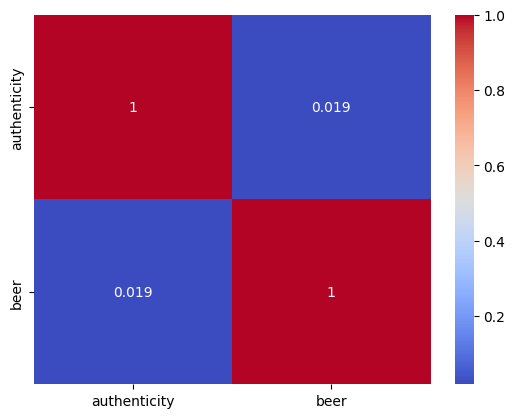

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
corr_matrix = X.corr().abs()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


In [37]:
from sklearn.model_selection import permutation_test_score
from sklearn.datasets import make_classification

X, y = make_classification(random_state=12345)
estimator = LogisticRegressionCV()
score, permutation_scores, pvalue = permutation_test_score(
    estimator, X, y, random_state=12345
)
print(f"Original Score: {score:.3f}")
print(
    f"Permutation Scores: {permutation_scores.mean():.3f} +/- "
    f"{permutation_scores.std():.3f}"
)
print(f"P-value: {pvalue:.3f}")

Original Score: 0.850
Permutation Scores: 0.499 +/- 0.062
P-value: 0.010
